# Part 1: Neural Network Fundamentals and Training Behavior Analysis

In [1]:
%pip install pandas seaborn scikit-learn tensorflow


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Task 1 . Data Understanding

In [2]:
# Import Libraries

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [3]:
# Load Dataset
df = pd.read_csv("customer_churn_nn.csv")

df.head()

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [4]:
# Display First 5 Rows
df.head()

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [5]:
# Shape
print("Dataset Shape:", df.shape)

Dataset Shape: (2000, 17)


In [6]:
# Data Types
print(df.dtypes)

customer_id                         str
region                              str
plan_type                           str
contract_type                       str
payment_method                      str
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object


In [7]:
# Target Variable Description
print(df['churn'].value_counts())


churn
0    1969
1      31
Name: count, dtype: int64


In [8]:
# Missing Values
print(df.isnull().sum())

customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64


In [9]:
# Stastistical Summary
df.describe()

,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000,0.015500
std,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546,0.123561
min,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000,0.000000
75%,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000,0.000000
max,72.000000,2156.520000,30.000000,8.000000,31.000000,265.510000,10.00000,424.000000,20.000000,1.000000,7.000000,1.000000


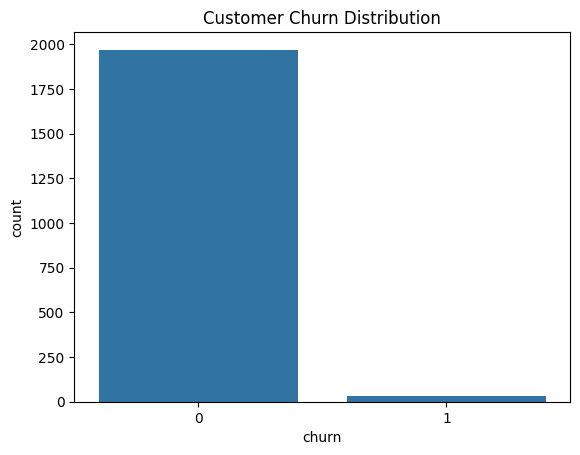

In [10]:
# Plot Target Distribution
sns.countplot(x='churn', data=df)

plt.title("Customer Churn Distribution")
plt.show()

### Task 2 — Data Preprocessing

In [11]:
# Remove Customer ID
df.drop("customer_id", axis=1, inplace=True)

# Separate Features and Target
X = df.drop("churn", axis=1)
y = df["churn"]

In [12]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    df[col].fillna(df[col].mean(), inplace=True)

C:\Users\Shivangi\AppData\Local\Temp\ipykernel_34028\2997319193.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].mean(), inplace=True)


In [13]:
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\Shivangi\AppData\Local\Temp\ipykernel_34028\3199972163.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns
C:\Users\Shivangi\AppData\Local\Temp\ipykernel_34028\3199972163.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For exam

In [14]:
X = pd.get_dummies(X, drop_first=True)

In [15]:
print(X.head())

   tenure_months  monthly_charges_inr  avg_login_days_per_month  \
0             30               687.40                        13   
1             15              1029.74                        22   
2             72               732.07                        13   
3             22               959.51                        19   
4             11               890.20                        18   

   support_tickets_last_90_days  payment_delay_days  data_usage_gb  \
0                             0                   0          87.97   
1                             3                   1          82.17   
2                             0                  11          89.39   
3                             2                   3         139.73   
4                             2                   6         156.43   

   satisfaction_score  last_complaint_days_ago  discount_percent  \
0                 8.0                       67                 0   
1                 5.7                   

In [16]:
# Train- Test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
# Verify Shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1600, 24)
X_test shape: (400, 24)
y_train shape: (1600,)
y_test shape: (400,)


### Task 3 — Build Neural Network

In [19]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [20]:
# Create Model
model = Sequential()

# Input + Hidden Layer 1
model.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))

# Hidden Layer 2
model.add(Dense(8, activation='relu'))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

# Compile Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

c:\Users\Shivangi\Downloads\ai_project_synthetic_datasets-20260516T060838Z-3-001\ai_project_synthetic_datasets\part_1_neural_network_analysis\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
#Model Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545 (2.13 KB)

 Trainable params: 545 (2.13 KB)

 Non-trainable params: 0 (0.00 B)

### Task 4— Training and evaluation

In [22]:
history = model.fit(
    X_train,
    y_train,
    epochs=50, #The model will learn from the dataset 50 times.
    batch_size=32, #The model processes 32 samples at once before updating weights.
    validation_split=0.2  #20% of training data is used for validation.
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.4781 - loss: 0.7469 - val_accuracy: 0.6750 - val_loss: 0.5885
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8547 - loss: 0.4452 - val_accuracy: 0.9312 - val_loss: 0.3602
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9727 - loss: 0.2671 - val_accuracy: 0.9750 - val_loss: 0.2321
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9867 - loss: 0.1682 - val_accuracy: 0.9781 - val_loss: 0.1694
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9867 - loss: 0.1200 - val_accuracy: 0.9781 - val_loss: 0.1388
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9867 - loss: 0.0966 - val_accuracy: 0.9781 - val_loss: 0.1242
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9867 - loss: 0.0840 - val_accuracy: 0.9781 - val_loss: 0.1175
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9867 - loss: 0.0768 - val_accuracy: 0.9781 - val_loss

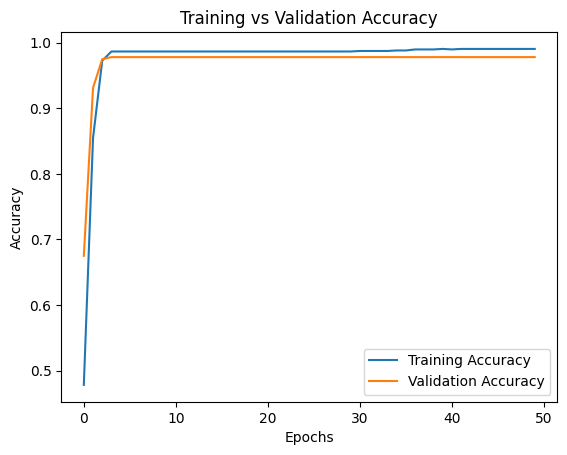

In [23]:
# plot training accuracy
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()
plt.savefig("results/training_accuracy_plot.png")
plt.show()

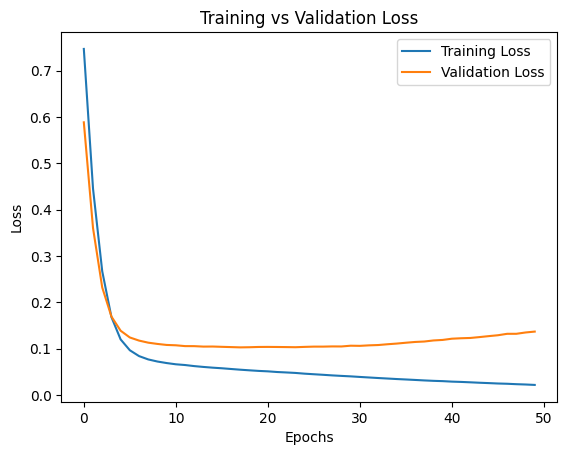

In [24]:
# Plot Training Loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()
plt.savefig("results/training_loss_plot.png")
plt.show()

In [25]:
# Evaluate on Test Data

loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9825 - loss: 0.0675  
Test Loss: 0.0675143450498581
Test Accuracy: 0.9825000166893005


98.25% Accuracy: The model shows high overall accuracy, with stable training and validation curves.

In [26]:
# Predictions
y_pred = model.predict(X_test)

# Convert probabilities into classes
y_pred = (y_pred > 0.5).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


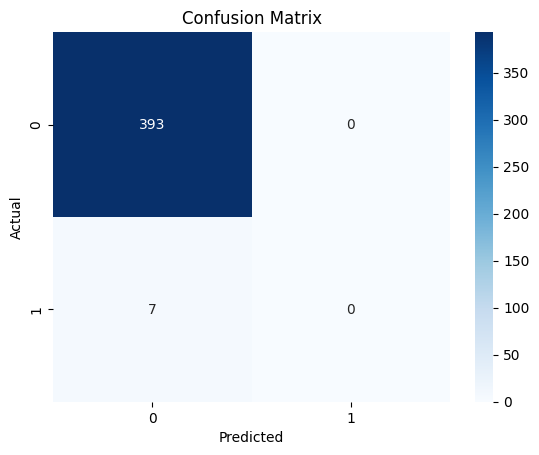

In [27]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("results/confusion_matrix.png")
plt.show()

Severe Imbalance: Out of 400 test samples, 393 are class 0 (retained) and only 7 are class 1 (churned).

In [28]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       393
           1       0.00      0.00      0.00         7

    accuracy                           0.98       400
   macro avg       0.49      0.50      0.50       400
weighted avg       0.97      0.98      0.97       400



c:\Users\Shivangi\Downloads\ai_project_synthetic_datasets-20260516T060838Z-3-001\ai_project_synthetic_datasets\part_1_neural_network_analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Shivangi\Downloads\ai_project_synthetic_datasets-20260516T060838Z-3-001\ai_project_synthetic_datasets\part_1_neural_network_analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Shivangi\Downloads\ai_project_synthetic_datasets-20260516T060838Z-3-001\ai_project_synthetic_data

Zero Churn Detection: The model failed to catch a single churn case, resulting in 0.00 Precision and Recall for class 1.

Misleading Metric: This proves that high accuracy can be completely misleading when a dataset is heavily skewed.

Fixes Needed: Future iterations require techniques like SMOTE, adjusting class_weight, or focusing on the F1-Score.

The model achieved high accuracy but struggled to detect minority-class churn cases due to class imbalance.

In [29]:
plt.savefig("results/evaluation_outputs.png")

<Figure size 640x480 with 0 Axes>

### Task 5 — Hyperparameter Experiments

In [30]:
# Experiment 1 — Baseline
model1 = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model1.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    verbose=0
)

acc1 = model1.evaluate(X_test, y_test, verbose=0)[1]

c:\Users\Shivangi\Downloads\ai_project_synthetic_datasets-20260516T060838Z-3-001\ai_project_synthetic_datasets\part_1_neural_network_analysis\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
# Experiment 2 — More Neurons
model2 = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model2.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    verbose=0
)

acc2 = model2.evaluate(X_test, y_test, verbose=0)[1]


In [32]:
# Experiment 3 — Different Activation
model3 = Sequential([
    Dense(16, activation='tanh', input_shape=(X_train.shape[1],)),
    Dense(8, activation='tanh'),
    Dense(1, activation='sigmoid')
])

model3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model3.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    verbose=0
)

acc3 = model3.evaluate(X_test, y_test, verbose=0)[1]

In [33]:
# Comparison Table
import pandas as pd

results = pd.DataFrame({
    "Experiment": [
        "Baseline",
        "More Neurons",
        "Tanh Activation"
    ],
    
    "Hidden Layers": [
        "16-8",
        "32-16",
        "16-8"
    ],
    
    "Activation": [
        "ReLU",
        "ReLU",
        "Tanh"
    ],
    
    "Batch Size": [
        32,
        32,
        16
    ],
    
    "Accuracy": [
        acc1,
        acc2,
        acc3
    ]
})

print(results)

        Experiment Hidden Layers Activation  Batch Size  Accuracy
0         Baseline          16-8       ReLU          32    0.9825
1     More Neurons         32-16       ReLU          32    0.9775
2  Tanh Activation          16-8       Tanh          16    0.9775


In [34]:
import os

# Save Results
os.makedirs("results", exist_ok=True)
results.to_csv("results/model_comparison_table.csv", index=False)


## Task 6 — Final Reflection

#### 1. What Role does Weights and Bias play in the model
Weights determine the importance of each input feature in prediction.

Biases help shift activation values and improve model flexibility.

Together, they allow the neural network to learn patterns from data


#### 2. Why is an Activation Functions Required

Activation functions introduce non-linearity into the model.

Without activation functions, the neural network behaves like a simple linear model and cannot learn complex relationships.

Example ReLU activation:

f(x)=max(0,x)

#### 3. What Happens when leaning rate is too high or too low Learning Rate

##### Learning Rate Too High
* Training becomes unstable
* Loss may oscillate
* Model may fail to converge

##### Learning Rate Too Low
* Training becomes very slow
* Model may get stuck before reaching optimal performance

#### 4. Did your Model Shows signs of overfitting or underfitting? Explain

The test accuracies were very high across all configurations:

Baseline: 98.25%
More neurons: 97.50%
Tanh activation: 98.25%

The model did not show obvious signs of underfitting or overfitting. Underfitting is unlikely because the model achieved high accuracy on the test data, meaning it captured the important patterns in the dataset. Overfitting is also not strongly indicated because different model configurations produced similarly high test accuracy, and the larger model did not perform much better than the baseline. This suggests the model generalized well to unseen data.